<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#FashionMNIST" data-toc-modified-id="FashionMNIST-1"><span class="toc-item-num">1&nbsp;&nbsp;</span><b>FashionMNIST</b></a></span></li><li><span><a href="#FashionMNIST" data-toc-modified-id="FashionMNIST-2"><span class="toc-item-num">2&nbsp;&nbsp;</span><b>FashionMNIST</b></a></span></li><li><span><a href="#Данные" data-toc-modified-id="Данные-3"><span class="toc-item-num">3&nbsp;&nbsp;</span><b>Данные</b></a></span></li><li><span><a href="#Задание" data-toc-modified-id="Задание-4"><span class="toc-item-num">4&nbsp;&nbsp;</span><b>Задание</b></a></span></li></ul></div>

---

<h2 style="text-align: center;"><b>FashionMNIST</b></h2>

---

В этом ноутбуке Вам предстоит самостоятельно попрактиковаться в написаноо нейросетей для распознавания датасета, похожего на MNIST, но более интересного -- чёрно-белых изображений одежды.

<h2 style="text-align: center;"><b>FashionMNIST</b></h2>

<img src="https://emiliendupont.github.io/imgs/mnist-chicken/mnist-and-fashion-examples.png">

<h2 style="text-align: center;"><b>Данные</b></h2>

Мы будем работать с картинками одежды (чёрно-белыми, то есть цветовых каналов не 3, а 1). По входной картинке нужно предсказать тип одежды.

In [3]:
# !pip install torchvision

import numpy as np
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
import torch
import torchvision

In [4]:
transform = transforms.ToTensor()


trainset = torchvision.datasets.FashionMNIST(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=4,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.FashionMNIST(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=4,
                                         shuffle=False, num_workers=2)

classes = ('T-shirt/top', 'Trouser', 'Pullover', 'Dress',
           'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot')

Каждая картинка имеет класс от 0 до 9, расшифровка меток класса:  

|class_id|class_name|
|----|----|
|0| T-shirt/top|
|1| Trouser|
|2| Pullover|
|3| Dress|
|4| Coat|
|5| Sandal|
|6| Shirt|
|7| Sneaker|
|8| Bag|
|9| Ankle boot| 

Посмотрите на датасет.
* Сколько в нём классов?
* Сколько картинок в train? В test?
* Выведите несколько картинок с помощью `pyplot`

d:\anaconda\Lib\site-packages\torchvision\datasets\mnist.py:76: UserWarning: train_data has been renamed data
  warnings.warn("train_data has been renamed data")
d:\anaconda\Lib\site-packages\torchvision\datasets\mnist.py:81: UserWarning: test_data has been renamed data
  warnings.warn("test_data has been renamed data")


torch.Size([60000, 28, 28])
torch.Size([10000, 28, 28])


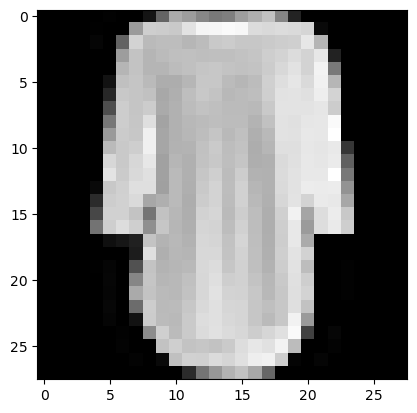

In [5]:
print(trainloader.dataset.train_data.shape)
print(testloader.dataset.test_data.shape)
i = np.random.randint(low=0, high=50000)
plt.imshow(trainloader.dataset.data[i], cmap='gray');

<h2 style="text-align: center;"><b>Задание</b></h2>

Используя материалы семинаров по многослойным  и свёрточным сетям, напишите Свёрточную сеть, классифицирующую этот датасет.
Если качество, которое получается у  нейросети, выше 95%, то Вы решили задачу с точностью, которую можно использовать в жизни.

In [6]:
import torch.nn as nn
import torch.nn.functional as F  


class SimpleConvNet(nn.Module):
    def __init__(self):
        # вызов конструктора предка
        super(SimpleConvNet, self).__init__()

        self.conv1 = nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5)
        self.fc1 = nn.Linear(4 * 4 * 16, 120)  # !!!
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        # print(x.shape)
        x = x.view(-1, 4 * 4 * 16)  # !!!
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [7]:
import torch
import torchvision
from torchvision import transforms

import numpy as np
import matplotlib.pyplot as plt
numpy_img = trainloader.dataset.train_data[0].numpy()

In [8]:
from tqdm import tqdm_notebook

# объявляем сеть
net = SimpleConvNet()

# выбираем функцию потерь
loss_fn = torch.nn.CrossEntropyLoss()

# выбираем алгоритм оптимизации и learning_rate
learning_rate = 1e-4
optimizer = torch.optim.Adam(net.parameters(), lr=learning_rate)

# итерируемся
for epoch in tqdm_notebook(range(3)):

    running_loss = 0.0
    for i, batch in enumerate(tqdm_notebook(trainloader)):
        # так получаем текущий батч
        X_batch, y_batch = batch
        
        # обнуляем веса
        optimizer.zero_grad()

        # forward + backward + optimize
        y_pred = net(X_batch)
        loss = loss_fn(y_pred, y_batch)
        loss.backward()
        optimizer.step()

        # выведем текущий loss
        running_loss += loss.item()
        # выведем качество каждые 2000 батчей
        if i % 2000 == 1999:
            print('[%d, %5d] loss: %.3f' %
                  (epoch + 1, i + 1, running_loss / 2000))
            running_loss = 0.0

print('Обучение закончено')

C:\Users\NND01\AppData\Local\Temp\ipykernel_16464\1543780392.py:14: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for epoch in tqdm_notebook(range(3)):


  0%|          | 0/3 [00:00<?, ?it/s]

C:\Users\NND01\AppData\Local\Temp\ipykernel_16464\1543780392.py:17: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for i, batch in enumerate(tqdm_notebook(trainloader)):


  0%|          | 0/15000 [00:00<?, ?it/s]

[1,  2000] loss: 1.212
[1,  4000] loss: 0.774
[1,  6000] loss: 0.689
[1,  8000] loss: 0.644
[1, 10000] loss: 0.615
[1, 12000] loss: 0.605
[1, 14000] loss: 0.569


  0%|          | 0/15000 [00:00<?, ?it/s]

[2,  2000] loss: 0.556
[2,  4000] loss: 0.523
[2,  6000] loss: 0.531
[2,  8000] loss: 0.532
[2, 10000] loss: 0.497
[2, 12000] loss: 0.486
[2, 14000] loss: 0.475


  0%|          | 0/15000 [00:00<?, ?it/s]

[3,  2000] loss: 0.485
[3,  4000] loss: 0.446
[3,  6000] loss: 0.448
[3,  8000] loss: 0.437
[3, 10000] loss: 0.437
[3, 12000] loss: 0.439
[3, 14000] loss: 0.416
Обучение закончено


In [9]:
class_correct = list(0. for i in range(10))
class_total = list(0. for i in range(10))

with torch.no_grad():
    for data in testloader:
        images, labels = data
        y_pred = net(images)
        _, predicted = torch.max(y_pred, 1)
        c = (predicted == labels).squeeze()
        for i in range(4):
            label = labels[i]
            class_correct[label] += c[i].item()
            class_total[label] += 1

for i in range(10):
    print('Accuracy of %5s : %2d %%' % (
        classes[i], 100 * class_correct[i] / class_total[i]))

Accuracy of T-shirt/top : 81 %
Accuracy of Trouser : 94 %
Accuracy of Pullover : 71 %
Accuracy of Dress : 91 %
Accuracy of  Coat : 79 %
Accuracy of Sandal : 93 %
Accuracy of Shirt : 49 %
Accuracy of Sneaker : 89 %
Accuracy of   Bag : 96 %
Accuracy of Ankle boot : 96 %


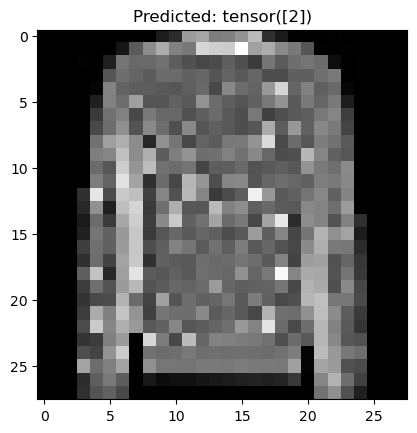

In [10]:
i = np.random.randint(low=0, high=10000)

def visualize_result(index):
    image = testloader.dataset.test_data[index].numpy()
    plt.imshow(image, cmap='gray')
    
    y_pred = net(torch.Tensor(image).view(1, 1, 28, 28))
    _, predicted = torch.max(y_pred, 1)
    
    plt.title(f'Predicted: {predicted}')

visualize_result(i)